This notebook summarizes the results across different noise types and levels. It also shows the effect of noise on force predictions.

In [51]:
import os
import sys
notebook_dir = os.getcwd()
project_dir = os.path.dirname(os.path.dirname(notebook_dir))

if project_dir not in sys.path:
    sys.path.insert(0, project_dir)
import logging
import json
from matplotlib import gridspec
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle as pkl
from force_regression.config.dataconfig import DataConfig
import force_regression.utils.functions as fn
import force_regression.utils.io as io
import force_regression.evaluation.compile_results as cr
from force_regression.models.snn import *
from hydra import initialize_config_dir, compose
import force_regression.utils.configuration as lrc
from configs.constants import *

print(f'Notebook dir: {notebook_dir}\nProject dir: {project_dir}.')

logging.getLogger().setLevel(logging.INFO)
%load_ext autoreload
%autoreload 2

Notebook dir: /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/notebooks/analysis
Project dir: /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
config_path = os.path.join(project_dir, 'configs/config.json')

try:
    with open(config_path, 'r') as config_file:
        config = json.load(config_file)
        root_dir = os.path.join(project_dir, config['root_dir'])
        subject_mappings = config['subject_mappings']
        root_results_dir = os.path.join(project_dir, config['root_results_dir'])
        config['root_dir'] = root_dir
        config['root_results_dir'] = root_results_dir
        print(f'Root directory from config: {root_dir}')
except FileNotFoundError:
    print(f"Error: 'config.json' not found in {config_path}")
except json.JSONDecodeError:
    print("Error: 'config.json' is not a valid JSON file.")
except KeyError:
    print("Error: 'root_dir' not found in 'config.json'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

results_dir = 'output_files'
source_data_main_file = 'SourceDataMain.xlsx'
source_data_si_file = 'SourceDataSupplementary.xlsx'

Root directory from config: /Volumes/big usb drive/HDiEMG_mu_decomposition


# Data configuration

In [3]:
SELECT_TORCH_SEED = 90

In [4]:
# used to retrieve the figs_dir
data_config = DataConfig(root_dir=root_dir,
                         root_results_dir = root_results_dir,
                          subject=fn.reverse_remap("S1", subject_mappings),
                          task_type="Trap",
                          finger_type="Individual",
                          day="Day 1",
                          emg_type="surf",
                          f_samp=10240,
                          subj_map=subject_mappings,
                          segment_hold=True, 
                          verbose=False,
                          common_only=True,
                          images=False,
                          time_to_cut=1,
                          results_dir=results_dir)
output_figures_dir = os.path.join(data_config.root_results_dir, data_config.figs_dir)


In [5]:
save_figure = False
type_pred_metric = 'post'
subjects = ["S1","S2"]

models_palette_dict = {'intra mu spike count': '#FF6F5C',
                       f'intra mu spike times {SHALLOW_LEAKY}': sns.color_palette(palette='Accent')[0],
                       f'intra mu spike times {SHALLOW_SPIKING_DOUBLE_FILTER}': COLORS['belize'],
                       }
topology_legend_name_map = {SHALLOW_LEAKY:'LI', SHALLOW_SPIKING_DOUBLE_FILTER:'LIF'}

# Load SNN and LR results

In [6]:
mvcs_list = [15]
metrics_compiled_df_snn_spiking = pd.DataFrame()
metrics_compiled_df_snn_leaky = pd.DataFrame()
metrics_compiled_df_conv = pd.DataFrame()
y_compiled_df_snn_spiking = pd.DataFrame()
y_compiled_df_snn_leaky = pd.DataFrame()
y_compiled_df_conv = pd.DataFrame()

noise_modes = ['omission', 'addition', 'misattribution']
for noise_mode in noise_modes:
    metrics_temp_df = cr.load_and_parse_snn_data_to_df(dt=0.01,
                                                       subject_list=subjects,
                                                       data_type='metrics_df_cv_snn',
                                                       network_topology=f'{SHALLOW_SPIKING_DOUBLE_FILTER}/noise/{noise_mode}',
                                                       results_dir=results_dir,
                                                       config=config)
    metrics_compiled_df_snn_spiking = pd.concat([metrics_compiled_df_snn_spiking, metrics_temp_df], ignore_index=True)
    y_compiled_temp_df = cr.load_and_parse_snn_data_to_df(dt=0.01,
                                                          subject_list=subjects,
                                                          data_type='y_df_cv_snn',
                                                          network_topology=f'{SHALLOW_SPIKING_DOUBLE_FILTER}/noise/{noise_mode}',
                                                          results_dir=results_dir,
                                                          config=config)
    y_compiled_df_snn_spiking = pd.concat([y_compiled_df_snn_spiking, y_compiled_temp_df], ignore_index=True)

    metrics_temp_df = cr.load_and_parse_snn_data_to_df(dt=0.01, subject_list=subjects,
                                                       data_type='metrics_df_cv_snn',
                                                       network_topology=f'{SHALLOW_LEAKY}/noise/{noise_mode}',
                                                       results_dir=results_dir,
                                                       config=config)
    metrics_compiled_df_snn_leaky = pd.concat([metrics_compiled_df_snn_leaky, metrics_temp_df], ignore_index=True)
    y_compiled_temp_df = cr.load_and_parse_snn_data_to_df(dt=0.01,
                                                          subject_list=subjects,
                                                          data_type='y_df_cv_snn',
                                                          network_topology=f'{SHALLOW_LEAKY}/noise/{noise_mode}',
                                                          results_dir=results_dir,
                                                          config=config)
    y_compiled_df_snn_leaky = pd.concat([y_compiled_df_snn_leaky, y_compiled_temp_df], ignore_index=True)

    # load baseline data
    metrics_temp_df = cr.load_and_parse_df_data(subject_list=subjects, data_type='metrics_df', config=config, 
                                                        results_dir=results_dir, is_noise_analysis=True,
                                                        noise_mode=noise_mode)
    metrics_compiled_df_conv = pd.concat([metrics_compiled_df_conv, metrics_temp_df], ignore_index=True)

    y_compiled_temp_df = cr.load_and_parse_df_data(subject_list=subjects, data_type='y_df',
                                                            config=config, results_dir=results_dir,
                                                            is_multi=False,is_noise_analysis=True,
                                                            noise_mode = noise_mode)
    y_compiled_df_conv = pd.concat([y_compiled_df_conv, y_compiled_temp_df], ignore_index=True)
    

Loading data for subject S1 from /Volumes/big usb drive/snn-fingerforce-decoding-results/results/output_files/S1/SNN/shallow_spiking_double_filter/noise/omission
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_omission_percent_10_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_omission_percent_10_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_omission_percent_0_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_omission_percent_20_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_omission_percent_30_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt

Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_0_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_30_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_50_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_40_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_20_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading data for subject S2 from /Volumes/big usb drive/snn-fingerforce-decoding-results/results/output_files/S2/SNN/shallow_spiking_double_filter/n

Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_10_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_0_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_30_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_50_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_40_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_20_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_1_mvc_15_k

Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_omission_percent_0_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_omission_percent_20_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_omission_percent_0_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_omission_percent_30_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_omission_percent_40_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_omission_percent_40_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics

Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_50_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_10_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_40_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_20_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_20_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_90_noise_omission_percent_0_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading data for subject S2 from /Volumes/big usb drive/

...

INFO:root:Loaded data for 2 subjects: ['S1' 'S2']
MVC:[15]
Window size: [0.08]
Overlap: [50]
Sign MVC: [-1  1]



metrics_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_20_ns_100.pkl
metrics_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_10_ns_100.pkl
metrics_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_5_ns_100.pkl
metrics_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_1_ns_100.pkl
metrics_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_50_ns_100.pkl
metrics_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_3_ns_100.pkl
metrics_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_3_ns_100.pkl
metrics_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_1_ns_100.pkl
me

y_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_15_ns_100.pkl
y_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_5_ns_100.pkl
y_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_0_ns_100.pkl
y_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_10_ns_100.pkl
y_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_15_ns_100.pkl
y_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_3_ns_100.pkl
y_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_20_ns_100.pkl
y_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_20_ns_100.pkl
y_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2

INFO:root:Loaded data for 2 subjects: ['S1' 'S2']
MVC:[15]
Window size: [0.08]
Overlap: [50]
Sign MVC: [-1  1]



y_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_15_ns_100.pkl
y_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_3_ns_100.pkl
y_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_20_ns_100.pkl
y_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False_noise_miss_percent_20_ns_100.pkl


In [7]:
def mask_torch_seed(df, torch_seed):
    """
    Masks the dataframe based on the given torch seed.
    """
    if torch_seed is None:
        df_seed = df[df[TORCH_SEED_COL].isnull()]
    else:
        df_seed = df[df[TORCH_SEED_COL] == torch_seed]
    return df_seed

# Compute mean across folds

In [8]:
mean_std_df_snn = pd.DataFrame()
snn_samples = pd.DataFrame()

mean_std_df_conv = pd.DataFrame()
conv_samples = pd.DataFrame()


convreg_metric = 'post'
pvalue_on_metric = 'RMSE' # 'RMSE' or 'R2'
mvc = 15
aux_cols_conv = [FING_ID_COL, SUBJECT_COL, MVC_COL, SIGN_MVC_COL, NOISE_LEVEL_COL, NOISE_MODE_COL] 
aux_cols_snn =  [TAU_SYN_COL, TAU_MEM_COL, TAU_SYN_INIT_COL, TAU_MEM_INIT_COL,
                 TAU1_MEM_FILT_COL, TAU2_MEM_FILT_COL, EPOCHS_COL]

temp_snn_spiking_df, temp_snn_spiking_samples = cr.compute_mean_sd_snn_metric(metrics_compiled_df_snn_spiking,
                                                                mvc,
                                                                return_samples=True,
                                                                aux_cols=aux_cols_conv + aux_cols_snn)
temp_snn_leaky_df, temp_snn_leaky_samples = cr.compute_mean_sd_snn_metric(metrics_compiled_df_snn_leaky,
                                                                mvc,
                                                                return_samples=True,
                                                                aux_cols=aux_cols_conv + aux_cols_snn)
print(temp_snn_spiking_df[SUBJECT_COL].unique())

temp_conv_df, temp_conv_samples = cr.compute_mean_sd_baseline_noise_metric(compiled_df=metrics_compiled_df_conv,
                                                            mvc=mvc,
                                                            return_samples=True,
                                                            aux_cols=aux_cols_conv,
                                                            metric_type = convreg_metric
                                                            )
# add topology column to the dataframes
temp_snn_spiking_df[TOPOLOGY_COL] = SHALLOW_SPIKING_DOUBLE_FILTER
temp_snn_leaky_df[TOPOLOGY_COL] = SHALLOW_LEAKY
temp_snn_spiking_samples[TOPOLOGY_COL] = SHALLOW_SPIKING_DOUBLE_FILTER
temp_snn_leaky_samples[TOPOLOGY_COL] = SHALLOW_LEAKY

mean_std_df_snn = pd.concat([mean_std_df_snn, temp_snn_spiking_df, temp_snn_leaky_df], axis=0, ignore_index=True)
snn_samples = pd.concat([snn_samples, temp_snn_spiking_samples, temp_snn_leaky_samples], axis=0, ignore_index=True)
mean_std_df_conv = pd.concat([mean_std_df_conv, temp_conv_df], axis=0, ignore_index=True)
conv_samples = pd.concat([conv_samples, temp_conv_samples], axis=0, ignore_index=True)
    
# map finger name to integer for plotting
mean_std_df_conv[FING_ID_COL] = mean_std_df_conv[FING_NAME_COL].map({fing: idx for idx, fing in enumerate(fing_order)})
conv_samples[MODEL_SHORT_NAME_COL] = conv_samples.apply(lambda x:f"{x[EMG_COL]} {x[INPUT_TYPE_COL].lower()}", axis=1)
conv_samples = conv_samples[conv_samples[MODEL_SHORT_NAME_COL].isin(['intra mu spike count'])]


# filter out all nan columns and ensure that the right snn parameters are selected
snn_samples = snn_samples.dropna(axis=1, how='all')

# update snn_samples df to match the forat of metric_samples_per_mvc for computing the p-values
snn_aux_col = aux_cols_snn+ ['MAE_test','MSE_test', TEST_ON_REP, 'input_dur', REG_FING_COL, 'mode']
if pvalue_on_metric == 'RMSE':
    snn_aux_col += ['R2_test']
elif pvalue_on_metric == 'R2':
    snn_aux_col += ['RMSE_test']

snn_samples[MODEL_SHORT_NAME_COL] = snn_samples.apply(lambda x:f"{x[EMG_COL]} {x[INPUT_TYPE_COL].lower()}", axis=1)

# update to match the format of the metric_samples_per_mvc
snn_samples = snn_samples.rename(columns={f'{pvalue_on_metric}_test': f'{pvalue_on_metric}_test_{type_pred_metric}'})


Computing mean across 1 torch seeds:[90]
Computing mean across 1 torch seeds:[90]
['S1' 'S2']


In [9]:
mean_std_df_snn.groupby([NOISE_LEVEL_COL,TOPOLOGY_COL, NOISE_MODE_COL])[f'{RMSE_TEST}_mean'].count()

noise_level  topology                       noise_mode
0            shallow_leaky                  addition      20
                                            miss          20
                                            omission      20
             shallow_spiking_double_filter  addition      20
                                            miss          20
                                            omission      20
1            shallow_leaky                  addition      20
                                            miss          20
             shallow_spiking_double_filter  addition      20
                                            miss          20
2            shallow_leaky                  addition      20
             shallow_spiking_double_filter  addition      20
3            shallow_leaky                  addition      20
                                            miss          20
             shallow_spiking_double_filter  addition      20
                              

In [10]:
mean_std_df_conv.groupby([NOISE_LEVEL_COL, NOISE_MODE_COL])[f'{RMSE_TEST}_mean'].count()

noise_level  noise_mode
0            addition      20
             miss          20
             omission      20
1            addition      20
             miss          20
2            addition      20
3            addition      20
             miss          20
4            addition      20
5            addition      20
             miss          20
10           addition      20
             miss          20
             omission      20
15           addition      20
             miss          20
20           addition      20
             miss          20
             omission      20
25           addition      20
30           addition      20
             omission      20
35           addition      20
40           addition      20
             omission      20
50           addition      20
             miss          20
             omission      20
Name: RMSE_test_mean, dtype: int64

In [11]:
metrics_list = [RMSE_TEST, R2_TEST, MAE_TEST]
metrics_list = [f"{metric}_mean" for metric in metrics_list] + [f"{metric}_std" for metric in metrics_list]

topology_mean_per_level = pd.DataFrame()
for topology in [SHALLOW_LEAKY, SHALLOW_SPIKING_DOUBLE_FILTER]:
    topology_mean_metrics = mean_std_df_snn[mean_std_df_snn[TOPOLOGY_COL]==topology]
    print(f"Topology: {topology} | {topology_mean_metrics.shape}")
    temp_df = topology_mean_metrics.groupby([SUBJECT_COL,NOISE_MODE_COL, NOISE_LEVEL_COL],as_index=False)[metrics_list].mean()
    temp_df[TOPOLOGY_COL] = topology
    topology_mean_per_level = pd.concat([topology_mean_per_level, temp_df], axis=0, ignore_index=True)
topology_mean_per_level

Topology: shallow_leaky | (520, 21)
Topology: shallow_spiking_double_filter | (520, 21)


,subject,noise_mode,noise_level,RMSE_test_mean,R2_test_mean,MAE_test_mean,RMSE_test_std,R2_test_std,MAE_test_std,topology
0,S1,addition,0,1.742199,0.892582,1.099033,0.317479,0.036553,0.173219,shallow_leaky
1,S1,addition,1,1.740461,0.892754,1.097127,0.317583,0.036460,0.169936,shallow_leaky
2,S1,addition,2,1.739261,0.892867,1.096631,0.315219,0.036104,0.165337,shallow_leaky
3,S1,addition,3,1.738227,0.89296,1.096491,0.313433,0.035777,0.162350,shallow_leaky
4,S1,addition,4,1.738916,0.892829,1.097585,0.310129,0.035363,0.160174,shallow_leaky
...,...,...,...,...,...,...,...,...,...,...
99,S2,omission,10,2.139635,0.845314,1.478574,0.547707,0.077775,0.510796,shallow_spiking_double_filter
100,S2,omission,20,2.263286,0.826827,1.578647,0.553838,0.083607,0.521910,shallow_spiking_double_filter
101,S2,omission,30,2.460937,0.795436,1.729269,0.580622,0.093449,0.555864,shallow_spiking_double_filter
102,S2,omission,40,2.741683,0.748283,1.923804,0.554232,0.098105,0.568043,shallow_spiking_double_filter


In [14]:
# get mean across fingers for the baseline model per noise level
baseline_mean_per_level = mean_std_df_conv.groupby([SUBJECT_COL,NOISE_MODE_COL, NOISE_LEVEL_COL], as_index=False)[metrics_list].mean()
baseline_mean_per_level.head(10)

,subject,noise_mode,noise_level,RMSE_test_mean,R2_test_mean,MAE_test_mean,RMSE_test_std,R2_test_std,MAE_test_std
0,S1,addition,0,1.731890,0.882191,1.005091,0.259363,0.040077,0.184089
1,S1,addition,1,1.730825,0.882330,1.004901,0.260110,0.040206,0.182816
2,S1,addition,2,1.732327,0.882112,1.006364,0.260641,0.040156,0.182421
3,S1,addition,3,1.729697,0.882440,1.005852,0.269555,0.041044,0.189560
4,S1,addition,4,1.730881,0.882234,1.008717,0.278348,0.041929,0.196148
5,S1,addition,5,1.733622,0.882030,1.012223,0.285346,0.042713,0.202385
6,S1,addition,10,1.774650,0.876715,1.046395,0.314286,0.046992,0.230721
7,S1,addition,15,1.861829,0.865028,1.101867,0.357506,0.052357,0.272588
8,S1,addition,20,1.969991,0.849680,1.173096,0.399966,0.059198,0.320348
9,S1,addition,25,2.112718,0.828002,1.261913,0.430197,0.066978,0.363357


In [55]:
def create_rmse_per_noise_level(topology_mean_per_level:pd.DataFrame,
                                baseline_mean_per_level:pd.DataFrame,
                                models_palette_dict:dict[str,str],
                                save_figure:bool=False, noise_seed:int=None,
                                noise_mode:str='omission',
                                source_data_file_name:str=None,
                                sheet_name:str='RMSE_per_noise_level'):
    
    topology_legend_map = {SHALLOW_LEAKY:'SNN LI', SHALLOW_SPIKING_DOUBLE_FILTER:'SNN LIF'}
    topology_color_dict = {SHALLOW_LEAKY: sns.color_palette(palette='Accent')[0],
                           SHALLOW_SPIKING_DOUBLE_FILTER: COLORS['belize']}
    fig = plt.figure(figsize=(8,3)) 
    gs = gridspec.GridSpec(1, 2)
    # figure styling
    scatter_plot_alpha = 0.8
    shaded_area_alpha = 0.2

    metric = RMSE
    metric_mean = f"{metric}_test_mean"
    noise_topology_mean_per_level = topology_mean_per_level[topology_mean_per_level[NOISE_MODE_COL] == noise_mode]
    noise_baseline_mean_per_level = baseline_mean_per_level[baseline_mean_per_level[NOISE_MODE_COL]==noise_mode]

    max_noise_level = noise_topology_mean_per_level[NOISE_LEVEL_COL].max()
    for col, sub in enumerate(noise_topology_mean_per_level[SUBJECT_COL].unique()):
        ax = fig.add_subplot(gs[col])
        if baseline_mean_per_level is not None:
            baseline_mean_per_sub = noise_baseline_mean_per_level[(noise_baseline_mean_per_level[SUBJECT_COL] == sub) & (noise_baseline_mean_per_level[NOISE_LEVEL_COL] <=50)]
            ax.plot(baseline_mean_per_sub[NOISE_LEVEL_COL], baseline_mean_per_sub[metric_mean],'-D',
                    color=models_palette_dict['intra mu spike count'], linewidth=1, linestyle='--',
                    ms=5, alpha=scatter_plot_alpha, label='Baseline LR')
        topology_mean_per_sub = noise_topology_mean_per_level[noise_topology_mean_per_level[SUBJECT_COL] == sub]
        sns.scatterplot(data=topology_mean_per_sub, x=NOISE_LEVEL_COL, y=metric_mean, hue=TOPOLOGY_COL,
                        palette=topology_color_dict, ax=ax, alpha=scatter_plot_alpha-0.1,
                        style=TOPOLOGY_COL, s=50, 
                        edgecolor=COLORS['midnight_blue'], linewidth=0.5)

        ax.set_ylim([0,4.5])
        # use fill between to create shaded area
        for i, topology in enumerate(topology_mean_per_sub[TOPOLOGY_COL].unique()):
            mask = (topology_mean_per_sub[TOPOLOGY_COL] == topology)
            x = np.array(topology_mean_per_sub[NOISE_LEVEL_COL][mask].unique(),dtype=float)
            y = np.array(topology_mean_per_sub[metric_mean][mask].unique(),dtype=float)
            yerr = np.array(topology_mean_per_sub[f"{metric}_test_std"][mask].unique(),dtype=float)
            print(x, y, yerr, topology)
            ax.fill_between(x, y - yerr, y + yerr, alpha=shaded_area_alpha,
                        color=topology_color_dict[topology]) 
        # read markers
        handles, _ = ax.get_legend_handles_labels()
        
        if noise_mode == 'omission':
            x_label = 'Omitted spikes (%)'
        elif noise_mode == 'miss':
            x_label = 'Misattributed spikes (%)'
        else:
            x_label = 'Added spikes (%)'
        ax.set_xlabel(x_label)
        ax.set_ylabel(RMSE_LABEL)
        ax.set_title(f"Subject {sub.split('S')[-1]}")
        ax.legend_.remove()
        plt.xticks(rotation=0)
        sns.despine(ax=ax, top=True, right=True)
    legend_label = ['Baseline LR']
    legend_label += [f'SNN {topology_legend_map[topology]}' for topology in topology_color_dict.keys()]           

    fig.legend(handles=handles, labels=legend_label, loc='upper center', 
           bbox_to_anchor=(1.1, 0.9), ncols=1, frameon=False)
    fig.tight_layout()

    if save_figure:
        plt.savefig(os.path.join(output_figures_dir,
                                 f'RMSE_per_noise_{noise_mode}_single_noise_seed_{noise_seed}_post_with_baseline_max_{max_noise_level}.pdf'),
                              dpi=300, bbox_inches='tight')
        
        # Combine all plotted data
        baseline_to_save = noise_baseline_mean_per_level[noise_baseline_mean_per_level[NOISE_LEVEL_COL] <= 50].copy()
        baseline_to_save[TOPOLOGY_COL] = 'Baseline LR'
        all_plotted_data = pd.concat([noise_topology_mean_per_level, baseline_to_save], ignore_index=True)

        cols_to_save = [SUBJECT_COL, NOISE_MODE_COL, NOISE_LEVEL_COL, TOPOLOGY_COL, 
                        f"{metric}_test_mean", f"{metric}_test_std"]
        io.save_to_source_data(os.path.join(project_dir, source_data_file_name),
                            all_plotted_data[cols_to_save], sheet_name=sheet_name)


[ 0. 10. 20. 30. 40. 50.] [1.74219918 1.83747201 2.06670296 2.39752578 2.7908754  3.22395031] [0.31747908 0.33208127 0.3260593  0.27261979 0.23002838 0.2232705 ] shallow_leaky
[ 0. 10. 20. 30. 40. 50.] [1.83961578 1.87991139 1.98347778 2.16454545 2.42884886 2.81398612] [0.3122782  0.33590232 0.34984732 0.36545129 0.36279737 0.39524396] shallow_spiking_double_filter
[ 0. 10. 20. 30. 40. 50.] [2.31821478 2.41213632 2.59447271 2.85160063 3.16444705 3.52133194] [0.4616489  0.5402599  0.56903254 0.54417785 0.4811702  0.41775095] shallow_leaky
[ 0. 10. 20. 30. 40. 50.] [2.07571594 2.13963529 2.26328552 2.4609372  2.74168306 3.11017408] [0.53885918 0.54770739 0.55383795 0.58062191 0.55423179 0.54570054] shallow_spiking_double_filter
Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataMain.xlsx in sheet 'Fig5b_omission'.


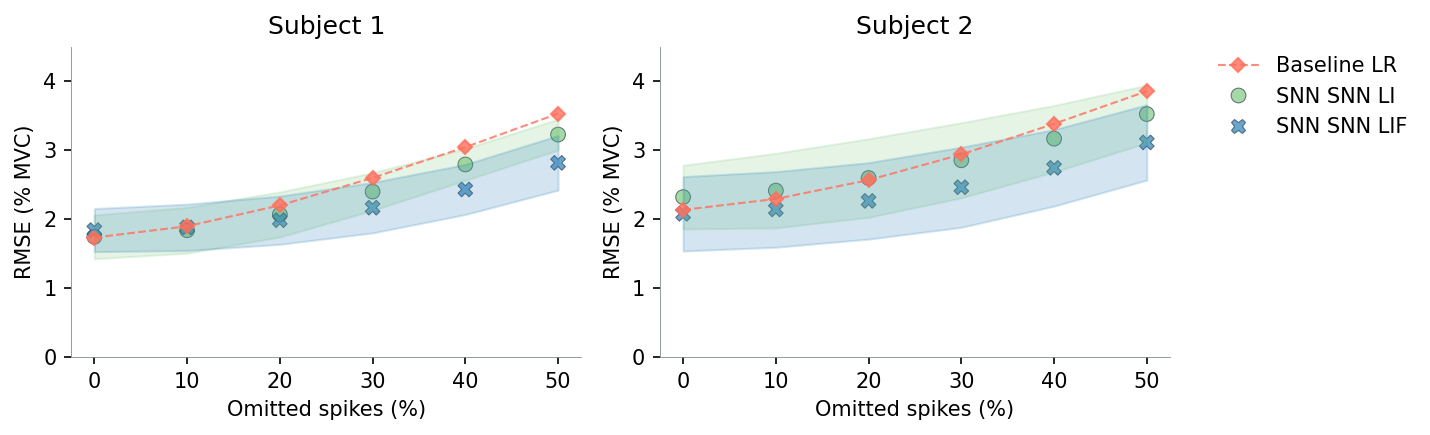

In [56]:
create_rmse_per_noise_level(topology_mean_per_level,baseline_mean_per_level,
                            models_palette_dict=models_palette_dict,
                            save_figure=True,
                            noise_seed =y_compiled_df_snn_spiking[NOISE_SEED_COL].unique()[0],
                            source_data_file_name=source_data_main_file,
                            sheet_name='Fig5b_omission')

[ 0. 10. 20. 30. 40. 50.] [1.74219918 1.77006791 1.91810905 2.15432131 2.44764993 2.77996964] [0.31747908 0.27838152 0.19975004 0.24062058 0.39854368 0.57258963] shallow_leaky
[ 0. 10. 20. 30. 40. 50.] [1.83961578 1.8984944  2.02084063 2.16131787 2.32200717 2.48351291] [0.3122782  0.28134977 0.26994267 0.31272459 0.37649923 0.45383494] shallow_spiking_double_filter
[ 0. 10. 20. 30. 40. 50.] [2.31821478 2.30288306 2.35955853 2.48046385 2.65210429 2.85982863] [0.4616489  0.38955671 0.37945815 0.3994083  0.48541158 0.65198459] shallow_leaky
[ 0. 10. 20. 30. 40. 50.] [2.07571594 2.11016267 2.20637071 2.33107405 2.47763835 2.64234568] [0.53885918 0.50870952 0.4835065  0.45684118 0.45560243 0.49067949] shallow_spiking_double_filter
Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataMain.xlsx in sheet 'Fig6b_addition'.


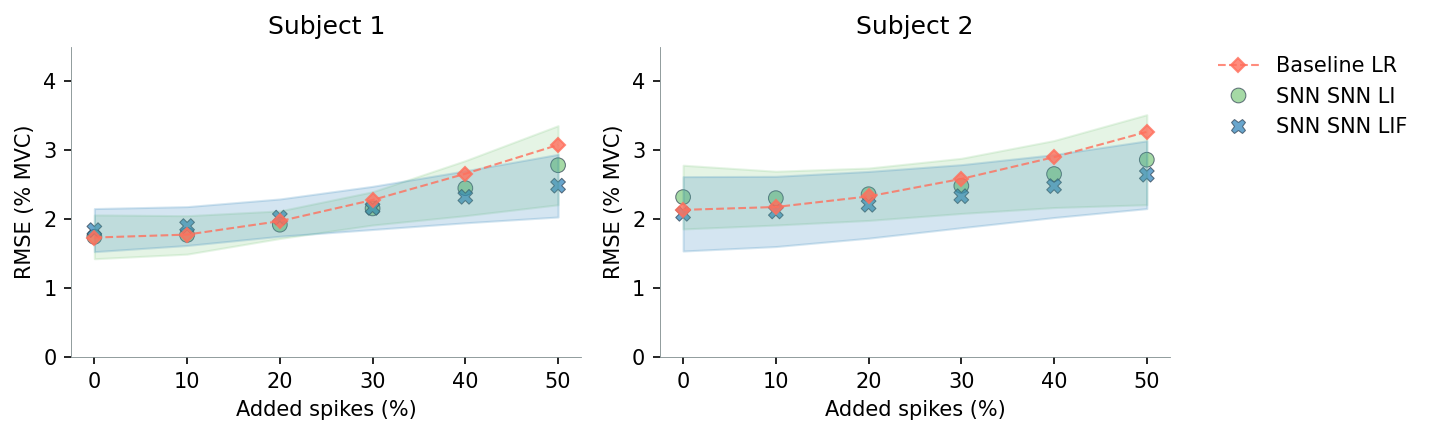

In [57]:
noise_levels = [0,10, 20, 30,40,50]
create_rmse_per_noise_level(topology_mean_per_level[topology_mean_per_level[NOISE_LEVEL_COL].isin(noise_levels)],
                            baseline_mean_per_level[baseline_mean_per_level[NOISE_LEVEL_COL].isin(noise_levels)],
                            models_palette_dict=models_palette_dict,
                            noise_mode='addition',
                            save_figure=True,
                            noise_seed =y_compiled_df_snn_spiking[NOISE_SEED_COL].unique()[0],
                            source_data_file_name=source_data_main_file,
                            sheet_name='Fig6b_addition')

[ 0.  1.  3.  5. 10. 15. 20.] [1.74219918 1.7430789  1.74314836 1.74393312 1.74852773 1.75054051
 1.75257128] [0.31747908 0.31641647 0.31564216 0.31482234 0.31812021 0.3264986
 0.32832016] shallow_leaky
[ 0.  1.  3.  5. 10. 15. 20.] [1.83961578 1.84557083 1.84269758 1.82833385 1.84278739 1.86163873
 1.88747761] [0.3122782  0.32057715 0.30838341 0.32028336 0.29812406 0.31606457
 0.314825  ] shallow_spiking_double_filter
[ 0.  1.  3.  5. 10. 15. 20.] [2.31821478 2.31807269 2.31855755 2.31933395 2.3232025  2.3287119
 2.33153296] [0.4616489  0.46429199 0.46867059 0.47469387 0.48518788 0.49319116
 0.50714143] shallow_leaky
[ 0.  1.  3.  5. 10. 15. 20.] [2.07571594 2.0766332  2.08213509 2.09173954 2.09993986 2.11339806
 2.13185527] [0.53885918 0.54281163 0.54849881 0.54277968 0.55815008 0.54738501
 0.53671361] shallow_spiking_double_filter
Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataMain.xlsx in sheet 'Fig7b_misattribution'.


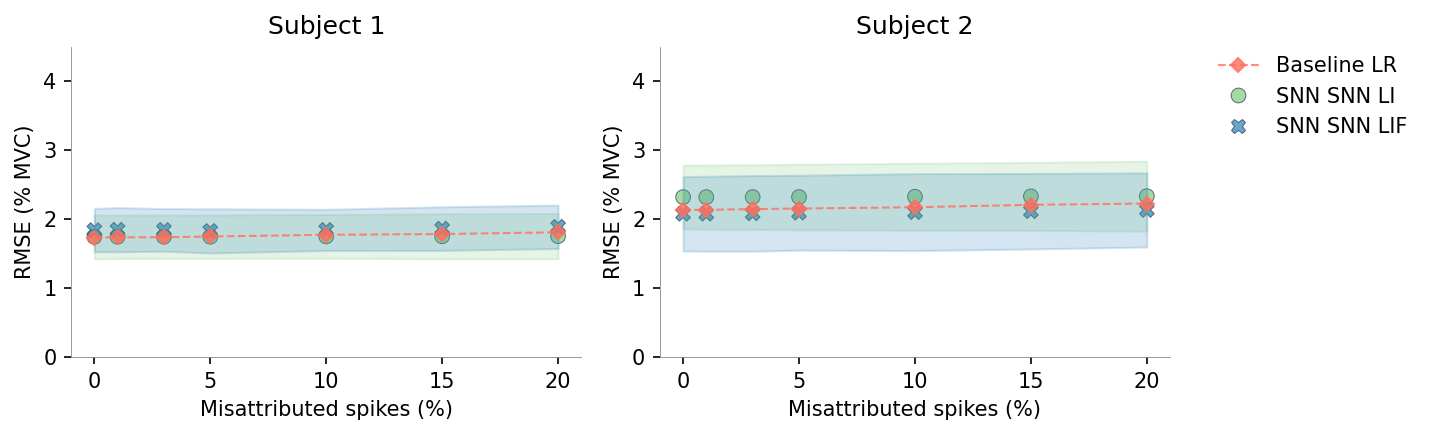

In [58]:
noise_levels = [0,1, 3, 5, 10, 15, 20] 
create_rmse_per_noise_level(topology_mean_per_level[topology_mean_per_level[NOISE_LEVEL_COL].isin(noise_levels)],
                            baseline_mean_per_level[baseline_mean_per_level[NOISE_LEVEL_COL].isin(noise_levels)],
                            models_palette_dict=models_palette_dict,
                            noise_mode='miss',
                            save_figure=True,
                            noise_seed =y_compiled_df_snn_spiking[NOISE_SEED_COL].unique()[0],
                            source_data_file_name=source_data_main_file,
                            sheet_name='Fig7b_misattribution')

In [50]:
baseline_mean_per_level[(baseline_mean_per_level[NOISE_LEVEL_COL]==50) &  (baseline_mean_per_level[SUBJECT_COL]=='S1')][[ 'noise_mode', SUBJECT_COL, 'RMSE_test_mean', 'RMSE_test_std']]

,noise_mode,subject,RMSE_test_mean,RMSE_test_std
13,addition,S1,3.073859,0.584692
21,miss,S1,1.936727,0.286073
27,omission,S1,3.527442,0.266091


In [20]:
topology_mean_per_level[(topology_mean_per_level[NOISE_LEVEL_COL]==50) &  (topology_mean_per_level[SUBJECT_COL]=='S1')][[ 'topology', 'noise_mode', SUBJECT_COL, 'RMSE_test_mean', 'RMSE_test_std']]

,topology,noise_mode,subject,RMSE_test_mean,RMSE_test_std
11,shallow_leaky,addition,S1,2.77997,0.572590
19,shallow_leaky,miss,S1,1.794704,0.338516
25,shallow_leaky,omission,S1,3.22395,0.223271
63,shallow_spiking_double_filter,addition,S1,2.483513,0.453835
71,shallow_spiking_double_filter,miss,S1,1.924008,0.277073
77,shallow_spiking_double_filter,omission,S1,2.813986,0.395244


In [ ]:
# Save to CSV files
topology_mean_per_level.to_csv(os.path.join(output_figures_dir,
                                            f'spikenoise_average_metrics_table_mvc_{mvc}_postfilt_torchseed_{SELECT_TORCH_SEED}.csv'), index=False)
baseline_mean_per_level.to_csv(os.path.join(output_figures_dir,
                                            f'baseline_spikenoise_average_metrics_table_mvc_{mvc}_postfilt_torchseed_{SELECT_TORCH_SEED}.csv'), index=False)

# Plot predictions across noise levels

In [25]:
# load SNN configurations
abs_config_dir=os.path.abspath("../../configs/hydra")
with initialize_config_dir(version_base=None, config_dir=abs_config_dir):
    cfg_leaky = compose(config_name="snn",
                  overrides=["decoder_type=leaky",
                            "logging.wandb.use_wandb=False",
                             ])
flat_leaky_config = lrc.flatten_hydra_config(cfg_leaky)


In [26]:
def segment_finger_data_from_array(unfolded_var, dataset, mvc, bin_size, rep_one_indexed, overlap_ratio=0.5):
    """
    Segments the unfolded variable into per-finger data.
    Inputs:
        unfolded_var: np.ndarray of shape (total_time_steps, n_fingers)
    Output:
        stitched_per_finger: dict of {finger_id: np.ndarray of shape (total_time_steps, n_fingers)}
    """
    stitched_per_finger = {}
    n_fingers= unfolded_var.shape[-1]
    segments_start_times = dataset.segments_start[mvc] 
    segment_n_steps = int(bin_size/dataset.dt)
    stride_in_steps = int(bin_size* (1 - overlap_ratio)/dataset.dt)

    finger_timesteps = int(dataset.segments_start[mvc][-1]/dataset.dt + segment_n_steps)
    arr_pointer = 0
    active_fingers_order = dataset.active_fingers_order[rep_one_indexed]
    for target_finger in active_fingers_order:
        stitched_spikes = np.zeros((finger_timesteps, n_fingers))
        for slice_i, _ in enumerate(segments_start_times):
            slice_start_loc = slice_i * stride_in_steps
            slice_end_loc = slice_start_loc + segment_n_steps
            # print(f"Slice start:{slice_start_loc}, slice end:{slice_end_loc}")  
            stitched_spikes[slice_start_loc: slice_end_loc] = unfolded_var[arr_pointer : arr_pointer+ segment_n_steps, :]
            arr_pointer += segment_n_steps
        stitched_per_finger[target_finger] = stitched_spikes
    return stitched_per_finger

In [27]:
def get_predictions_true_for_conditions(y_compiled_df: pd.DataFrame, 
                                   dataset,
                                   mvc: int,
                                   topology_config,
                                   noise_mode: str = 'addition',
                                   noise_level: int = 0,
                                   test_rep: int = 2,
                                   sign_mvc: int = -1,
                                   subject: str = 'S1') -> dict:
    """
    Filters dataframe for specific experimental conditions and segments predictions per finger.
    
    Args:
        y_compiled_df: DataFrame containing compiled predictions
        dataset: Dataset object with experimental metadata
        mvc: Maximum voluntary contraction level
        topology_config: Configuration object for a network topology
        noise_mode: Type of noise ('addition' or 'omission')
        noise_level: Noise level percentage
        test_rep: Repetition number (one-indexed)
        sign_mvc: Sign of MVC (-1 or 1)
        subject: Subject identifier (e.g., 'S1', 'S2')
    
    Returns:
        dict: Dictionary mapping finger_id to segmented prediction arrays
    """
    # Extract topology configuration parameters
    bin_size = topology_config.inf_rep_binwidth
    dt = topology_config.dt
    overlap_ratio = topology_config.overlap_perc
    
    # Filter dataframe based on experimental conditions
    selected_df = y_compiled_df[(y_compiled_df[NOISE_MODE_COL] == noise_mode) &
                                (y_compiled_df[NOISE_LEVEL_COL] == noise_level) &
                                (y_compiled_df['mode'] == 'inference') &
                                (y_compiled_df[SUBJECT_COL] == subject) &
                                (y_compiled_df[TEST_ON_REP] == test_rep) &
                                (y_compiled_df[SIGN_MVC_COL] == sign_mvc)]
    
    # Extract predictions and segment by finger
    pred_dict = segment_finger_data_from_array(
        selected_df[Y_PRED_TEST].iloc[0],
        dataset,
        mvc,
        bin_size,
        test_rep,
        overlap_ratio=overlap_ratio
    )
    true_dict = segment_finger_data_from_array(
        selected_df[Y_TRUE_TEST].iloc[0],
        dataset,
        mvc,
        bin_size,
        test_rep,
        overlap_ratio=overlap_ratio
    )
    
    return pred_dict, true_dict

In [28]:
dataset_filename = 'emgdataset_offline.pkl'
dataset_filepath = os.path.join(data_config.snn_temp_data_path, dataset_filename)
print(f"Dataset filepath:{dataset_filepath}")
#read the dataset
with open(dataset_filepath, 'rb') as handle:
    dataset = pkl.load(handle)

Dataset filepath:/Volumes/big usb drive/snn-fingerforce-decoding-results/results/snn_data/S1/emgdataset_offline.pkl


In [64]:
# mvc = 15

# test_rep = 1
# sign_mvc= 1
# test_subject = 'S1'
# noise_mode = 'addition'  # 'addition' or 'omission' or 'miss' (for misattribution)
# plot_noise_levels = [0, 10, 50]
# save_figure = True
# selected_topology = SHALLOW_SPIKING_DOUBLE_FILTER # SHALLOW_LEAKY | SHALLOW_SPIKING_DOUBLE_FILTER

# # Map topology to corresponding dataframe
# topology_df_map = { SHALLOW_LEAKY: y_compiled_df_snn_leaky,
#                     SHALLOW_SPIKING_DOUBLE_FILTER: y_compiled_df_snn_spiking
#                     }

# finger_id_to_name = {v: k for k, v in data_config.finger_label_map.items()}

# fig = plt.figure(figsize=(12,5))
# gs = gridspec.GridSpec(1, 5)
# true_force_alpha = 0.4
# for col, finger in enumerate(range(1,6,1)):
#     ax = fig.add_subplot(gs[col])
#     for nl, noise_level in enumerate(plot_noise_levels):
#         # Use the extracted method to get predictions
#         pred_dict, true_dict = get_predictions_true_for_conditions(
#             topology_df_map[selected_topology],
#             dataset,
#             mvc=mvc,
#             topology_config=flat_leaky_config,
#             noise_mode=noise_mode,
#             noise_level=noise_level,
#             test_rep=test_rep,
#             sign_mvc=sign_mvc,
#             subject=test_subject
#         )
#         time_axis = np.arange(pred_dict[finger].shape[0]) * flat_leaky_config.dt
#         rep_total_duration = pred_dict[finger].shape[0] * flat_leaky_config.dt

#         ax.plot(time_axis, pred_dict[finger][:,finger-1], color= data_config.finger_color_list[finger-1], linewidth=1.5,
#                 alpha = 1-nl * 0.22, label=f'noise level={noise_level}%')
#         ax.plot(time_axis, true_dict[finger][:,finger-1], color=COLORS['midnight_blue'], linewidth=1,
#                 alpha=true_force_alpha, label='True force' if nl==0 else None)
#     sns.despine(ax=ax, top=True, right=True)
#     # ax.set_title(f'{finger_id_to_name[finger]}')
#     ax.text(0.32, 0.9, f'{finger_id_to_name[finger]}', transform=ax.transAxes, fontsize=TITLE_FONTSIZE)
#     ax.set_xlabel(f"{TIME_LABEL}", fontsize=LABEL_FONTSIZE)
#     ax.set_xticks(np.arange(0, rep_total_duration, 10))
#     ax.set_ylim([-2, 28])

#     if col == 0:
#         ax.set_ylabel(FORCE_MVC_LABEL, fontsize=12)
#     else:
#         sns.despine(ax=ax, left=True)
#         ax.set_yticklabels([])
#         ax.set_yticks([])
#     handles, labels = ax.get_legend_handles_labels()
#     # Order: noise levels first, then 'True force'
#     ordered = sorted(zip(labels, handles), key=lambda x: (x[0] != 'True force', x[0]))
#     ordered_labels, ordered_handles = zip(*ordered)
#     ax.legend(ordered_handles, ordered_labels, frameon=False, fontsize=11,
#               bbox_to_anchor=(0.01, 1.55), loc='upper left')
# fig.tight_layout()

# # save figure
# if save_figure:
#     plt.savefig(os.path.join(output_figures_dir,
#                              f'SNN_{selected_topology}_predictions_per_finger_noise_{noise_mode}_mvc_{mvc}_rep_{test_rep}_subject_{test_subject}_post.pdf'),
#                 dpi=300, bbox_inches='tight')

In [62]:
def plot_predictions_per_finger(
    test_subject: str,
    test_rep: int,
    noise_mode: str,
    plot_noise_levels: list,
    selected_topology: str,
    topology_df_map: dict,
    topology_config,
    mvc: int = 15,
    sign_mvc: int = 1,
    save_figure: bool = False,
    source_data_file_name: str = None,
    sheet_name:str="predictions_per_noise_level"
):
    finger_id_to_name = {v: k for k, v in data_config.finger_label_map.items()}

    fig = plt.figure(figsize=(12, 5))
    gs = gridspec.GridSpec(1, 5)
    true_force_alpha = 0.4

    # Cache predictions to avoid double calls when saving
    cache = {}  # (finger, noise_level) -> (pred_dict, true_dict)
    for finger in range(1, 6):
        for noise_level in plot_noise_levels:
            cache[(finger, noise_level)] = get_predictions_true_for_conditions(
                topology_df_map[selected_topology], dataset, mvc=mvc,
                topology_config=topology_config, noise_mode=noise_mode,
                noise_level=noise_level, test_rep=test_rep,
                sign_mvc=sign_mvc, subject=test_subject
            )

    for col, finger in enumerate(range(1, 6)):
        ax = fig.add_subplot(gs[col])
        for nl, noise_level in enumerate(plot_noise_levels):
            pred_dict, true_dict = cache[(finger, noise_level)]
            time_axis = np.arange(pred_dict[finger].shape[0]) * topology_config.dt
            rep_total_duration = pred_dict[finger].shape[0] * topology_config.dt

            ax.plot(time_axis, pred_dict[finger][:, finger-1],
                    color=data_config.finger_color_list[finger-1], linewidth=1.5,
                    alpha=1 - nl * 0.22, label=f'noise level={noise_level}%')
            ax.plot(time_axis, true_dict[finger][:, finger-1],
                    color=COLORS['midnight_blue'], linewidth=1,
                    alpha=true_force_alpha, label='True force' if nl == 0 else None)

        sns.despine(ax=ax, top=True, right=True)
        ax.text(0.32, 0.9, f'{finger_id_to_name[finger]}', transform=ax.transAxes, fontsize=TITLE_FONTSIZE)
        ax.set_xlabel(TIME_LABEL, fontsize=LABEL_FONTSIZE)
        ax.set_xticks(np.arange(0, rep_total_duration, 10))
        ax.set_ylim([-2, 28])

        if col == 0:
            ax.set_ylabel(FORCE_MVC_LABEL, fontsize=12)
        else:
            sns.despine(ax=ax, left=True)
            ax.set_yticklabels([])
            ax.set_yticks([])

        handles, labels = ax.get_legend_handles_labels()
        ordered = sorted(zip(labels, handles), key=lambda x: (x[0] != 'True force', x[0]))
        ordered_labels, ordered_handles = zip(*ordered)
        ax.legend(ordered_handles, ordered_labels, frameon=False, fontsize=11,
                  bbox_to_anchor=(0.01, 1.55), loc='upper left')

    fig.tight_layout()

    if save_figure:
        plt.savefig(os.path.join(output_figures_dir,
                                 f'SNN_{selected_topology}_predictions_per_finger_noise_{noise_mode}_mvc_{mvc}_rep_{test_rep}_subject_{test_subject}_post.pdf'),
                    dpi=300, bbox_inches='tight')

        rows = []
        for finger in range(1, 6):
            for noise_level in plot_noise_levels:
                pred_dict, true_dict = cache[(finger, noise_level)]
                time_axis = np.arange(pred_dict[finger].shape[0]) * topology_config.dt
                for t, (pred, true) in enumerate(zip(pred_dict[finger][:, finger-1], true_dict[finger][:, finger-1])):
                    rows.append({
                        'subject': test_subject, 'noise_mode': noise_mode,
                        'noise_level': noise_level, 'finger': finger_id_to_name[finger],
                        'time_s': time_axis[t], 'predicted_force': pred, 'true_force': true
                    })
        source_df = pd.DataFrame(rows)
        io.save_to_source_data(os.path.join(project_dir, source_data_file_name),
                               source_df, sheet_name=sheet_name)
    return None


Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataSupplementary.xlsx in sheet 'SFig6a_omission_leaky'.


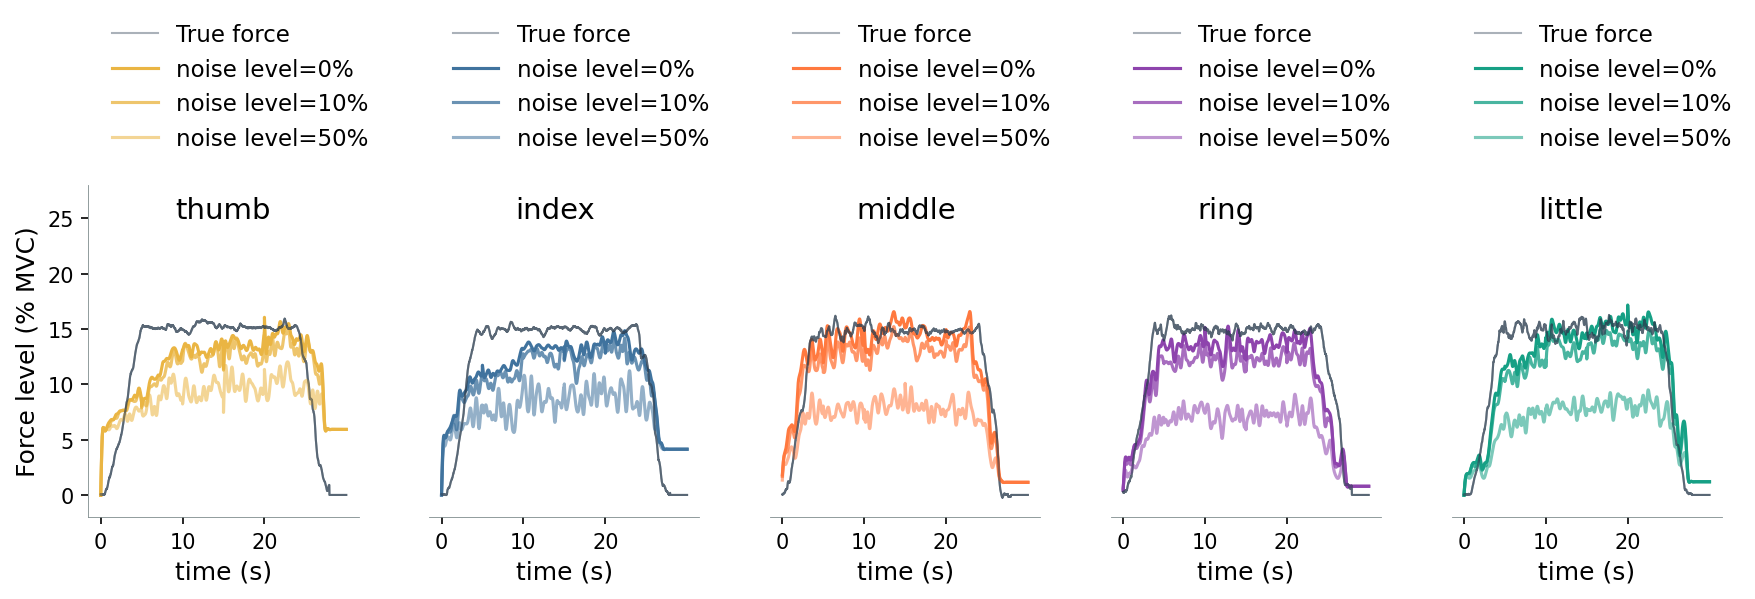

In [66]:
topology_df_map = {
    SHALLOW_LEAKY: y_compiled_df_snn_leaky,
    SHALLOW_SPIKING_DOUBLE_FILTER: y_compiled_df_snn_spiking
}

plot_predictions_per_finger(
    test_subject='S1',
    test_rep=1,
    noise_mode='omission',
    plot_noise_levels=[0, 10, 50],
    selected_topology=SHALLOW_LEAKY,
    topology_df_map=topology_df_map,
    topology_config=flat_leaky_config,
    save_figure=True,
    source_data_file_name=source_data_si_file,
    sheet_name='SFig6a_omission_leaky'
)


Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataSupplementary.xlsx in sheet 'SFig6b_omission_spiking'.


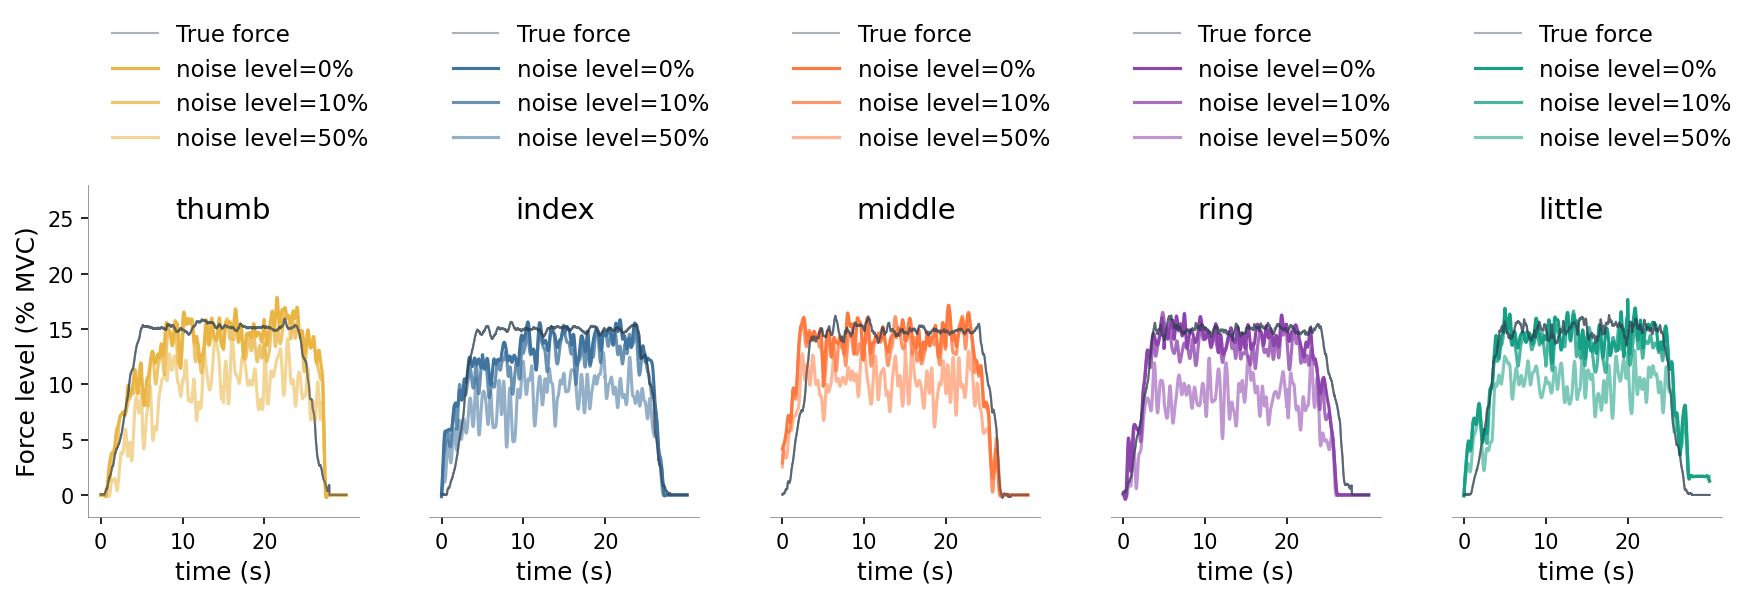

In [67]:
plot_predictions_per_finger(
    test_subject='S1',
    test_rep=1,
    noise_mode='omission',
    plot_noise_levels=[0, 10, 50],
    selected_topology=SHALLOW_SPIKING_DOUBLE_FILTER,
    topology_df_map=topology_df_map,
    topology_config=flat_leaky_config,
    save_figure=True,
    source_data_file_name=source_data_si_file,
    sheet_name='SFig6b_omission_spiking'
)


Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataSupplementary.xlsx in sheet 'SFig7a_addition_leaky'.


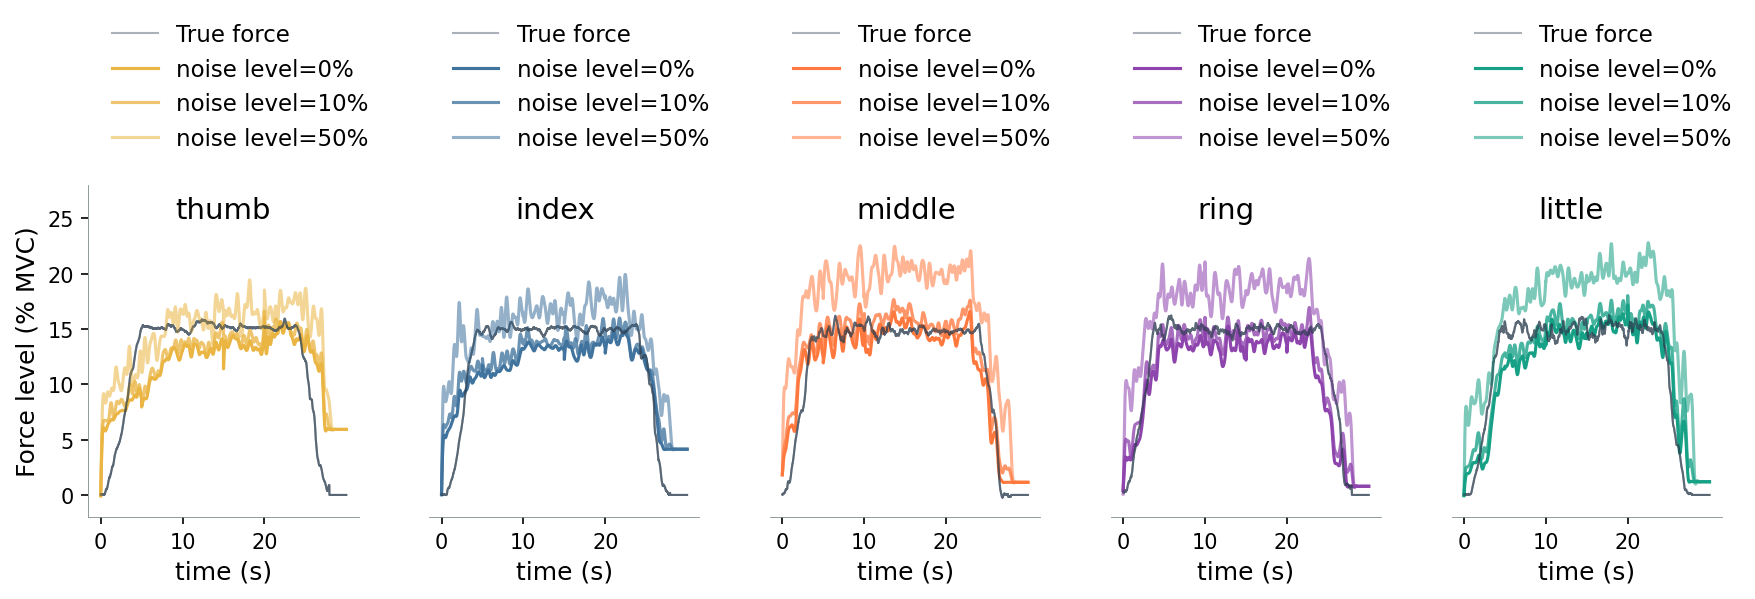

In [68]:
plot_predictions_per_finger(
    test_subject='S1',
    test_rep=1,
    noise_mode='addition',
    plot_noise_levels=[0, 10, 50],
    selected_topology=SHALLOW_LEAKY,
    topology_df_map=topology_df_map,
    topology_config=flat_leaky_config,
    save_figure=True,
    source_data_file_name=source_data_si_file,
    sheet_name='SFig7a_addition_leaky'
)


Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataSupplementary.xlsx in sheet 'SFig7b_addition_spiking'.


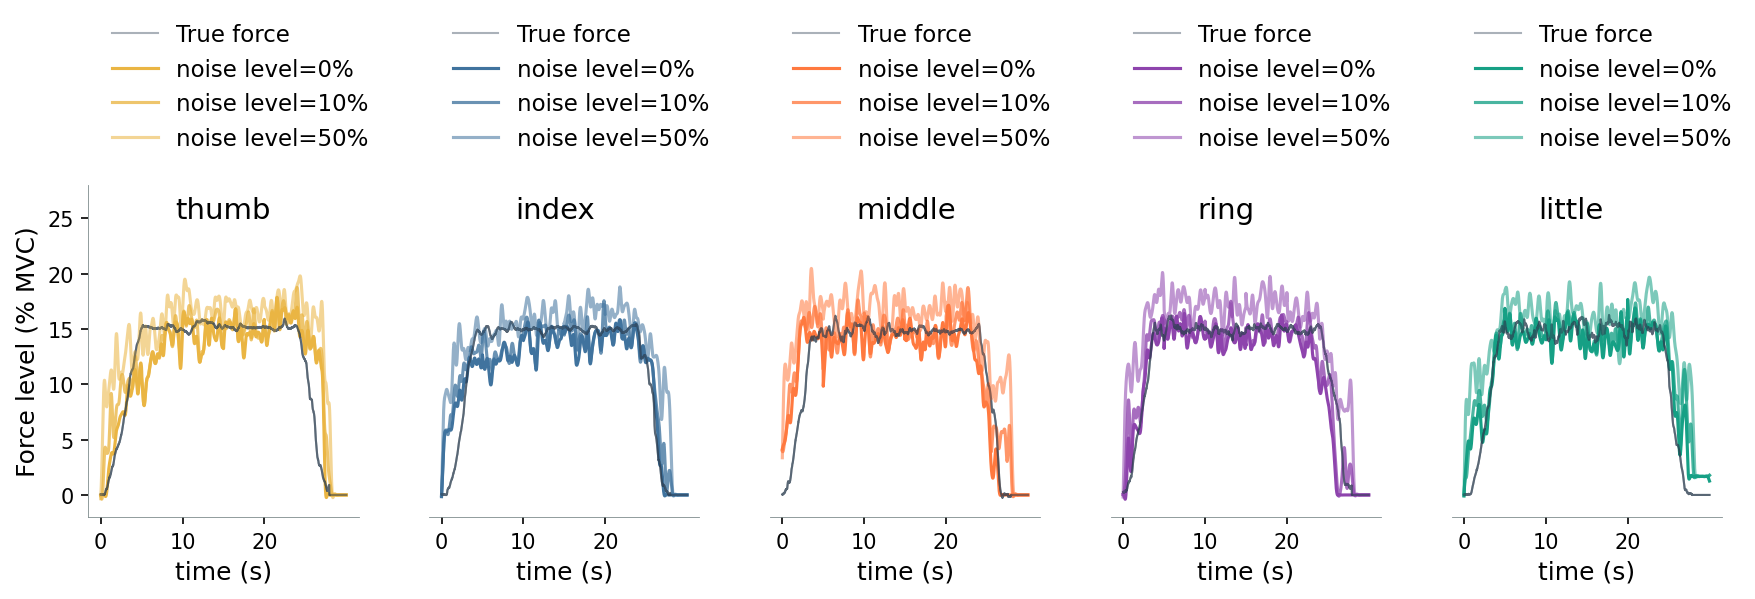

In [69]:
plot_predictions_per_finger(
    test_subject='S1',
    test_rep=1,
    noise_mode='addition',
    plot_noise_levels=[0, 10, 50],
    selected_topology=SHALLOW_SPIKING_DOUBLE_FILTER,
    topology_df_map=topology_df_map,
    topology_config=flat_leaky_config,
    save_figure=True,
    source_data_file_name=source_data_si_file,
    sheet_name='SFig7b_addition_spiking'
)


Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataSupplementary.xlsx in sheet 'SFig8a_addition_leaky_S2'.


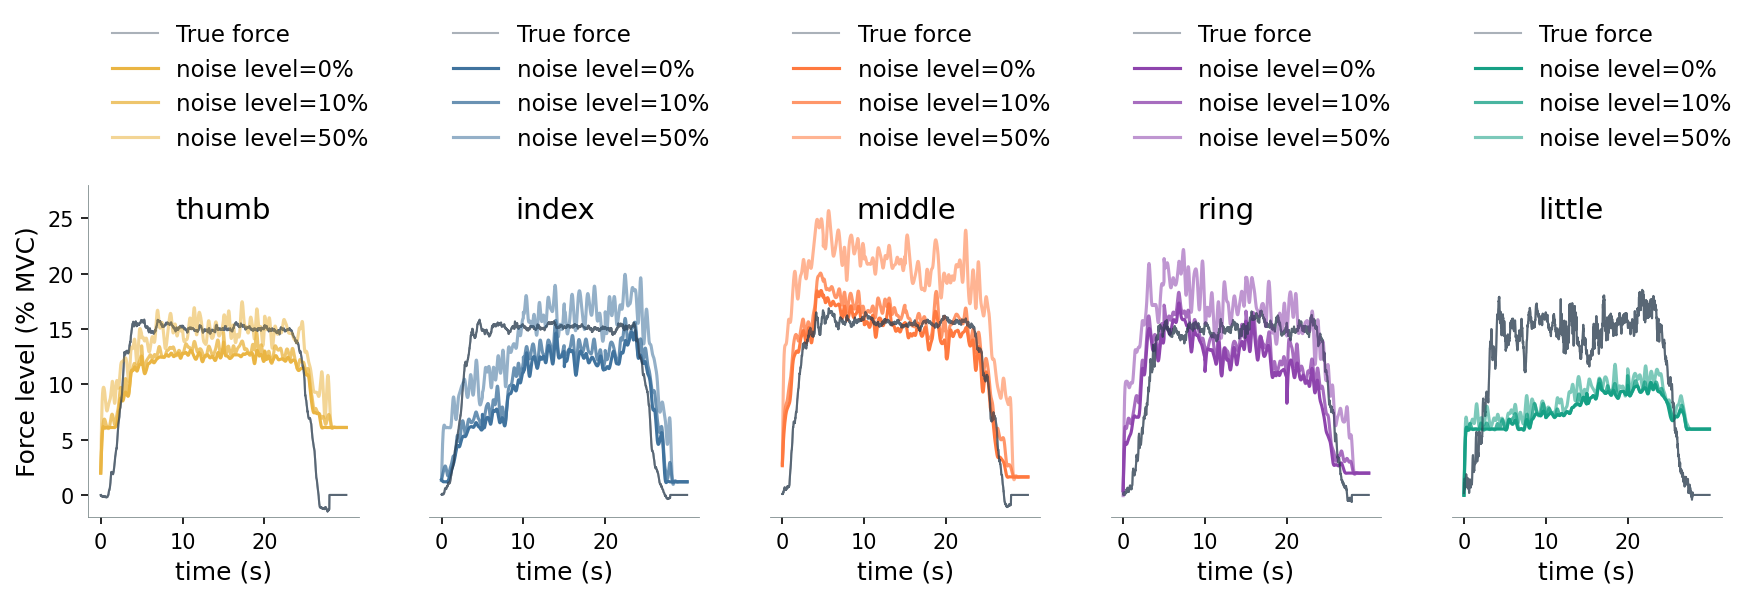

In [70]:
plot_predictions_per_finger(
    test_subject='S2',
    test_rep=1,
    noise_mode='addition',
    plot_noise_levels=[0, 10, 50],
    selected_topology=SHALLOW_LEAKY,
    topology_df_map=topology_df_map,
    topology_config=flat_leaky_config,
    save_figure=True,
    source_data_file_name=source_data_si_file,
    sheet_name='SFig8a_addition_leaky_S2'
)


Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataSupplementary.xlsx in sheet 'SFig8b_addition_spiking_S2'.


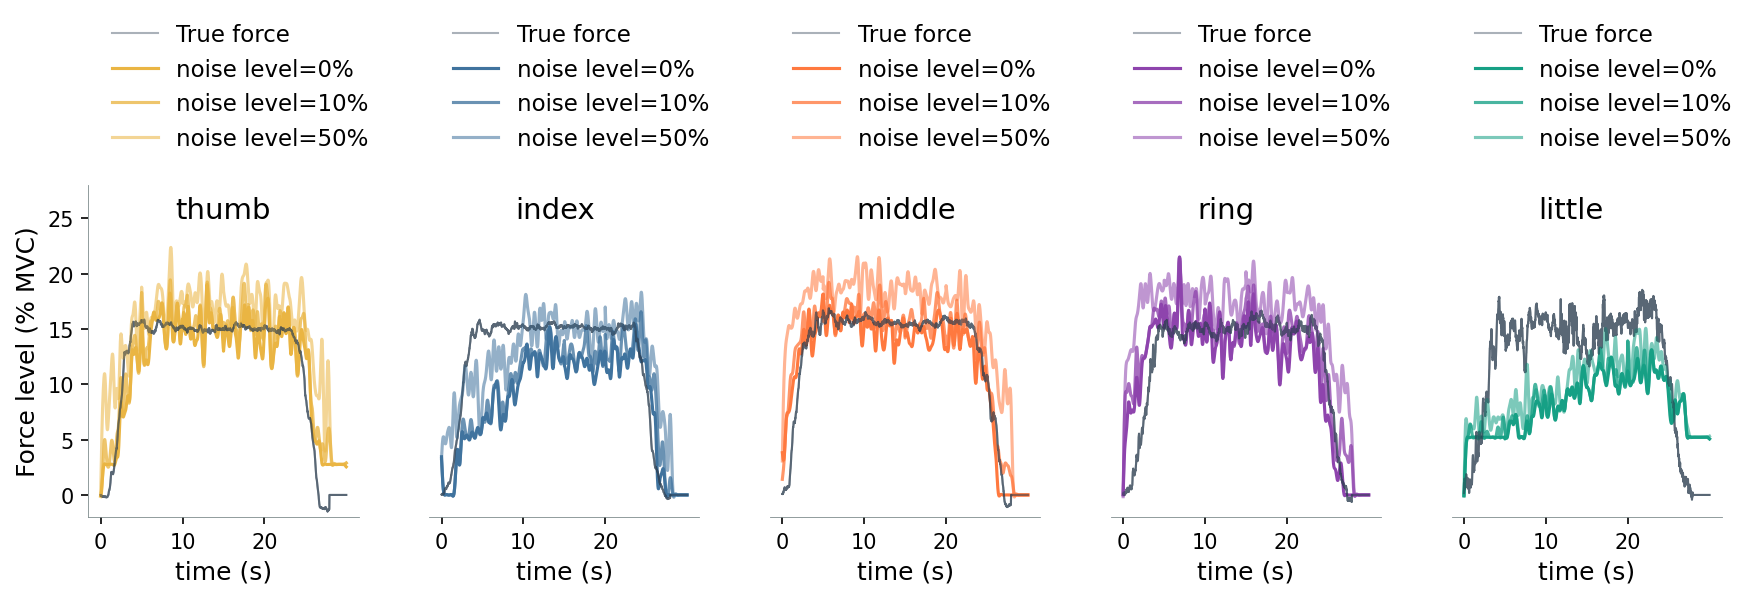

In [71]:
plot_predictions_per_finger(
    test_subject='S2',
    test_rep=1,
    noise_mode='addition',
    plot_noise_levels=[0, 10, 50],
    selected_topology=SHALLOW_SPIKING_DOUBLE_FILTER,
    topology_df_map=topology_df_map,
    topology_config=flat_leaky_config,
    save_figure=True,
    source_data_file_name=source_data_si_file,
    sheet_name='SFig8b_addition_spiking_S2'
)


Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataSupplementary.xlsx in sheet 'SFig9a_misattribution_leaky'.


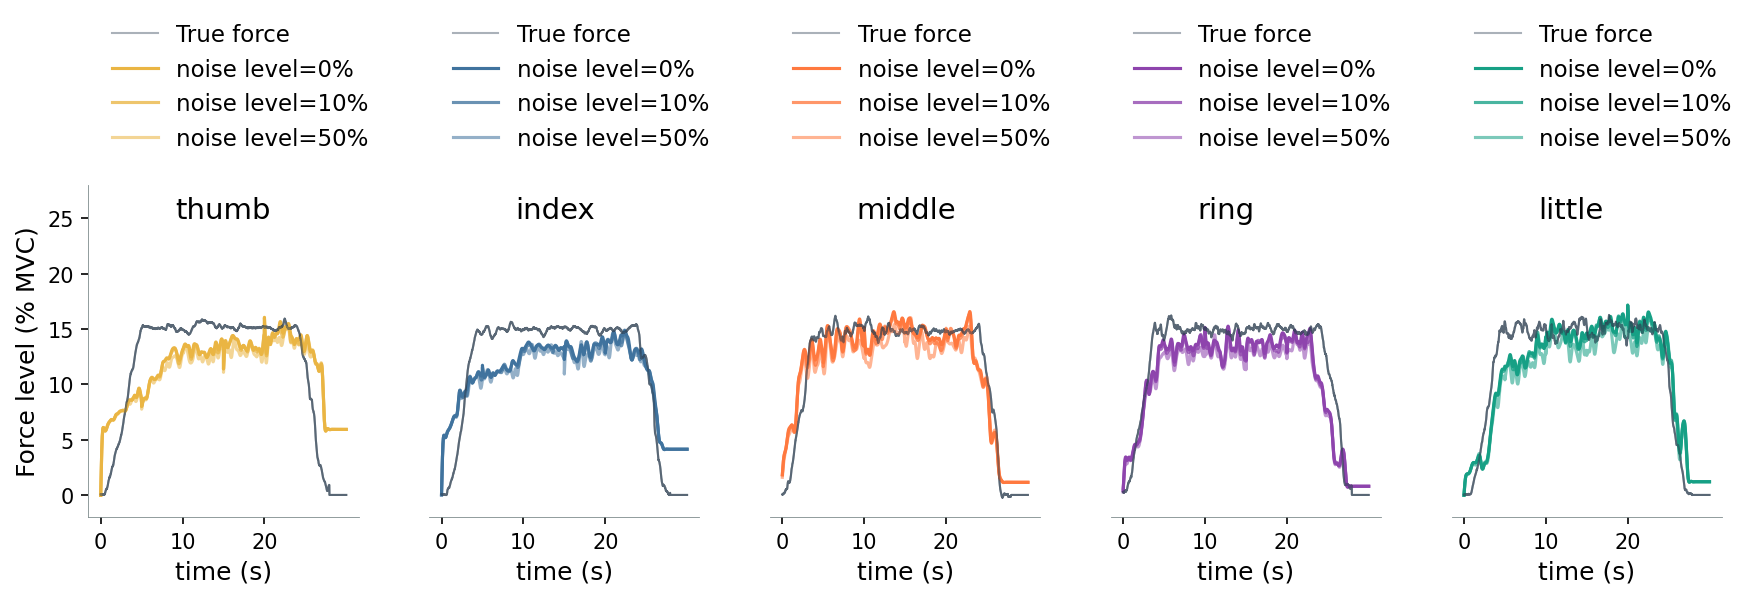

In [72]:
plot_predictions_per_finger(
    test_subject='S1',
    test_rep=1,
    noise_mode='miss',
    plot_noise_levels=[0, 10, 50],
    selected_topology=SHALLOW_LEAKY,
    topology_df_map=topology_df_map,
    topology_config=flat_leaky_config,
    save_figure=True,
    source_data_file_name=source_data_si_file,
    sheet_name='SFig9a_misattribution_leaky'
)


Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataSupplementary.xlsx in sheet 'SFig9b_misattribution_spiking'.


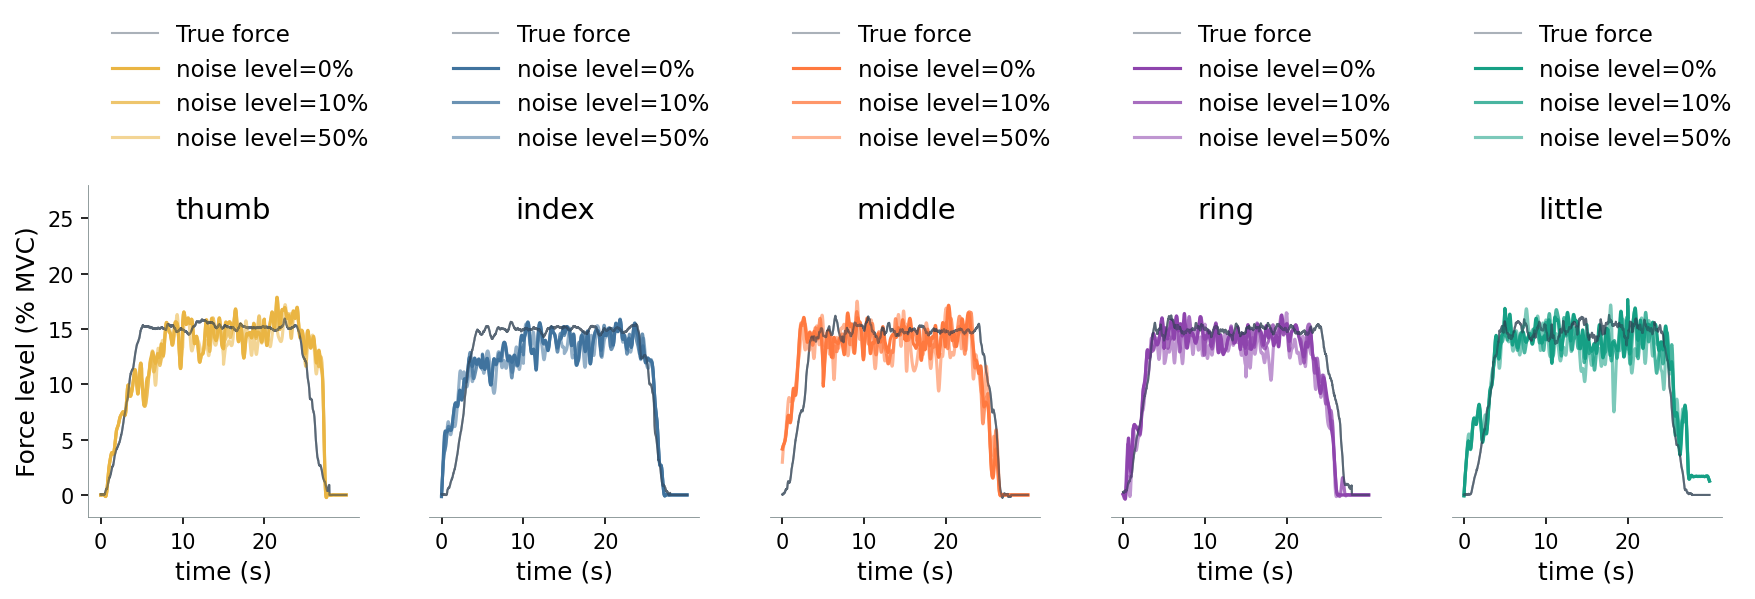

In [73]:
plot_predictions_per_finger(
    test_subject='S1',
    test_rep=1,
    noise_mode='miss',
    plot_noise_levels=[0, 10, 50],
    selected_topology=SHALLOW_SPIKING_DOUBLE_FILTER,
    topology_df_map=topology_df_map,
    topology_config=flat_leaky_config,
    save_figure=True,
    source_data_file_name=source_data_si_file,
    sheet_name='SFig9b_misattribution_spiking'
)
